# tACS Bandit: Main Analyses

**Study:** Examining the effects of theta-tACS over left DLPFC on reward-based learning across the adult lifespan

**Design:** Within-subject crossover (active vs. sham theta-tACS, 6 Hz)

This notebook orchestrates all pre-registered and exploratory analyses by calling modular functions. Individual modules contain the implementation details.

---
## 0. Setup & Imports

In [3]:
# Standard
import numpy as np
import pandas as pd
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Visualization
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.templates.default = 'plotly_white'

# Project modules
from config import *
from data_loading import load_all_subjects, summarize_loading
from exclusions import apply_all_exclusions
from sample_descriptives import run_sample_descriptives
from blinding_analysis import run_blinding_analysis
from wsls import run_wsls_analysis
from reversal_analysis import run_reversal_analysis
from rescorla_wagner import run_rw_analysis
from ddm import run_ddm_analysis
from eeg_theta import run_theta_analysis
from cognitive_merge import run_cognitive_merge
from hypothesis_tests import run_hypothesis_tests
from order_effects import run_order_effects_analysis
from correlations import run_correlation_analysis

print(f'Study: {len(SUBJECT_INFO)} participants in SUBJECT_INFO')
print(f'Data directory: {DATA_DIR}')

Study: 37 participants in SUBJECT_INFO
Data directory: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/data/bandit


---
## 1. Data Loading & Preprocessing

In [6]:
# Load all behavioral data
data = load_all_subjects()
summarize_loading(data)

Loading sub-10369...
  Run 1: 67 trials, 4 missed
  Run 2: 68 trials, 2 missed
  Run 3: 74 trials, 0 missed
  Run 4: 77 trials, 0 missed
  Run 5: 79 trials, 0 missed
  Run 6: 76 trials, 1 missed
  Run 7: 76 trials, 0 missed
  Run 8: 77 trials, 0 missed
Loading sub-10418...
  Run 1: 73 trials, 0 missed
  Run 2: 71 trials, 0 missed
  Run 3: 73 trials, 0 missed
  Run 4: 73 trials, 0 missed
  Run 5: 74 trials, 0 missed
  Run 6: 73 trials, 0 missed
  Run 7: 70 trials, 1 missed
  Run 8: 69 trials, 0 missed
Loading sub-10541...
  Run 1: 70 trials, 2 missed
  Run 2: 69 trials, 1 missed
  Run 3: 70 trials, 4 missed
  Run 4: 71 trials, 5 missed
  Run 5: 72 trials, 0 missed
  Run 6: 72 trials, 2 missed
  Run 7: 73 trials, 1 missed
  Run 8: 71 trials, 2 missed
Loading sub-10559...
  Run 1: 72 trials, 2 missed
  Run 2: 72 trials, 4 missed
  Run 3: 76 trials, 1 missed
  Run 4: 77 trials, 0 missed
  Run 5: 77 trials, 0 missed
  Run 6: 75 trials, 1 missed
  Run 7: 74 trials, 2 missed
  Run 8: 73 trial

,subject_id,n_runs,n_trials,n_missed,pct_missed,counterbalance,conditions
0,10369,8,594,7,1.178451,B,"[active, baseline, post, sham]"
1,10418,8,576,1,0.173611,B,"[active, baseline, post, sham]"
2,10541,8,568,17,2.992958,B,"[active, baseline, post, sham]"
3,10559,8,596,13,2.181208,A,"[active, baseline, post, sham]"
4,10589,8,597,3,0.502513,A,"[active, baseline, post, sham]"
5,10590,8,585,3,0.512821,B,"[active, baseline, post, sham]"
6,10606,8,598,2,0.334448,A,"[active, baseline, post, sham]"
7,10608,8,586,3,0.511945,A,"[active, baseline, post, sham]"
8,10636,8,611,3,0.490998,B,"[active, baseline, post, sham]"
9,10638,8,578,10,1.730104,B,"[active, baseline, post, sham]"


In [8]:
# Apply exclusion criteria
exclusion_results = apply_all_exclusions(data)

# Extract filtered datasets
data_h1 = exclusion_results['data_h1']       # H1 analyses: sham only, behavioral exclusions
data_h2 = exclusion_results['data_h2']       # H2 analyses: active vs sham, all exclusions
data_clean = exclusion_results['data_clean'] # All clean trials
run_exclusions = exclusion_results['run_exclusions']
h2_eligible = exclusion_results['h2_eligible']

print(f'\nH1-eligible subjects: {data_h1["subject_id"].nunique()}')
print(f'H2-eligible subjects: {len(h2_eligible)}')

Computing Pre-Registered Exclusion Criteria

Behavioral Exclusion Summary (Run-Level):
--------------------------------------------------
  ⚠ >20% missed trials: 1/288 runs (0%)
  ⚠ Side bias (>95%): 3/288 runs (1%)
  ⚠ Stimulus bias (>95%): 8/288 runs (3%)
  ⚠ Rapid responding (<200ms): 1/288 runs (0%)
  ⚠ Feedback invariance (10+ losses): 4/288 runs (1%)

Stimulation Administration Exclusions: 3 runs
  sub-10998 Run 6: Experimenter error: sham protocol loaded instead of active
  sub-11773 Run 6: Experimenter error: sham protocol loaded instead of active
  sub-11773 Run 7: Experimenter error: sham protocol loaded instead of active

Combined Exclusion Summary

Total subjects: 36
Total runs: 288
Runs excluded (behavioral): 16
Runs excluded (stim admin): 3
Unique runs excluded for H2: 18

H1 sample (sham, behavioral exclusions):
  36 subjects, 70 clean sham runs, 5182 trials

H2 sample (active vs. sham, all exclusions + min-run threshold):
  33 subjects eligible for paired comparisons, 9

---
## 2. Sample Descriptives & Demographics

Sample Descriptives

N = 37
Age: M = 44.8, SD = 19.6, range = 23–75

Gender:
  Female: 22 (59%)
  Male: 15 (41%)

Race:
  White: 28 (76%)
  Black or African American: 4 (11%)
  Asian: 3 (8%)
  Two or more races, or race not described (other): 2 (5%)

Ethnicity:
  Not Hispanic or Latino: 32 (86%)
  Hispanic or Latino: 4 (11%)
  Ethnicity not described (Other): 1 (3%)



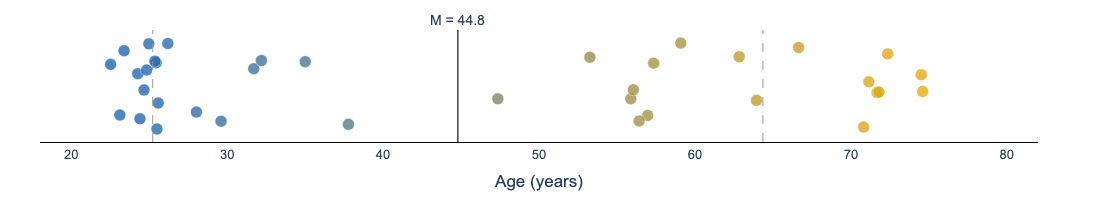


Estimated vs Actual Cap Size Comparison

Subjects with ICV data: 37
Subjects with both estimated and actual: 25
  Matches (same size): 15
  Off by 1 size: 9
  Off by 2 sizes: 1

Mismatch direction:
  Actual smaller than estimated: 9
  Actual larger than estimated: 1

 Subject      ICV      Estimated       Actual       Status
------------------------------------------------------------
   10369   1534.5          Large        Large      ✓ Match
   10418   1329.0              —       Medium   Incomplete
   10541   1614.6    Extra Large        Large    ✗ +1 size
   10559   1443.6          Large        Large      ✓ Match
   10589   1494.2          Large            —   Incomplete
   10590   1577.5    Extra Large            —   Incomplete
   10606   1489.6          Large        Large      ✓ Match
   10608   1197.5          Small        Small      ✓ Match
   10636   1313.4              —        Small   Incomplete
   10638   1235.7          Small        Small      ✓ Match
   10641   1313.5    

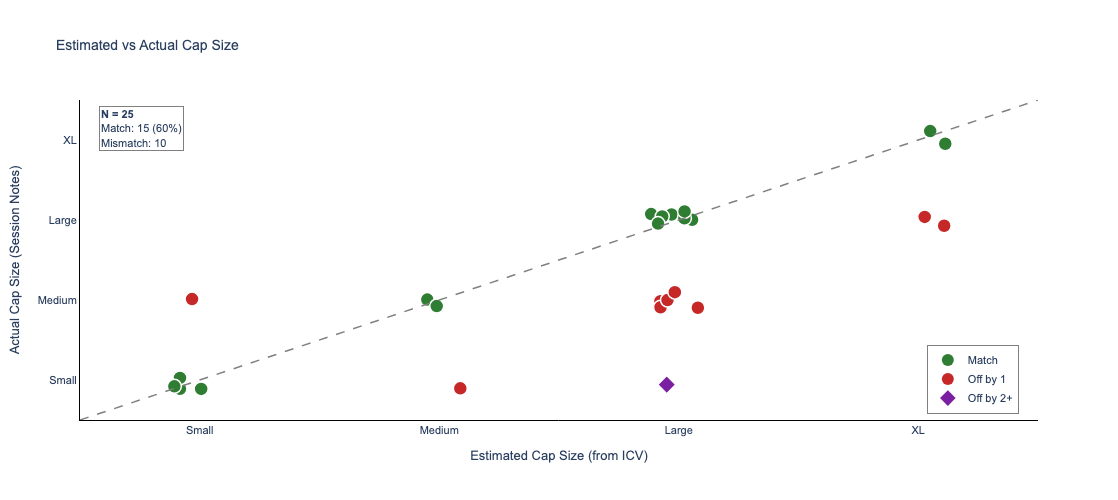

In [11]:
# Demographics and cap size analysis
desc_results = run_sample_descriptives()

---
## 3. Blinding Integrity

Blinding Integrity Analysis

Data: 133 run-level observations from 36 participants

--- Contingency Table ---
                 Participant Guess
Actual Condition   Active    Sham    Total
---------------------------------------------
     Active            47       20       67
      Sham             37       29       66
---------------------------------------------
     Total             84       49      133

--- Signal Detection Metrics ---
  Hits (say Active | Active):            47 / 67 = 70.1%
  Misses (say Sham | Active):            20 / 67 = 29.9%
  False Alarms (say Active | Sham):      37 / 66 = 56.1%
  Correct Rejections (say Sham | Sham):  29 / 66 = 43.9%

  d' (sensitivity):  +0.37  (near zero — no discrimination)
  c (criterion):     -0.34  (bias toward "Active")

  Overall accuracy: 57.1% (76/133)
  Binomial vs 50%: p = 0.118
  χ² = 2.26, p = 0.132

--- By Counterbalance Order ---
Order    N_runs        Hits          FA       d'      Acc
-----------------------------------

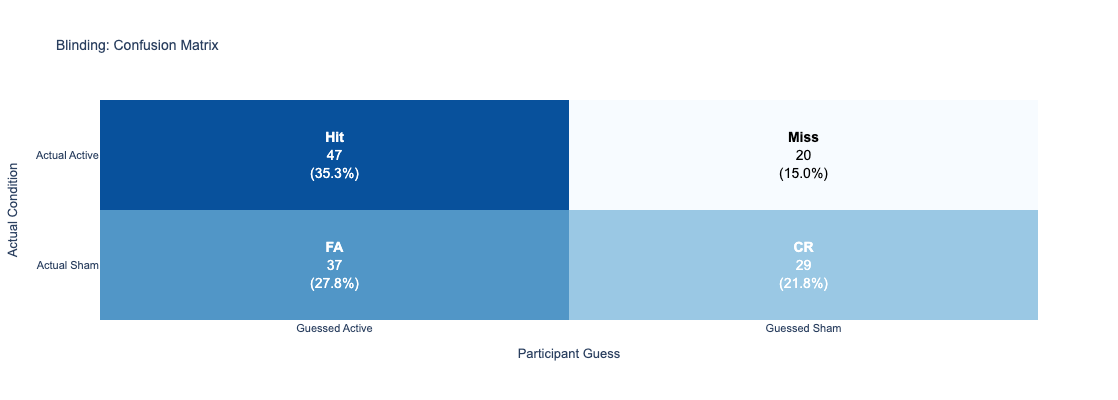

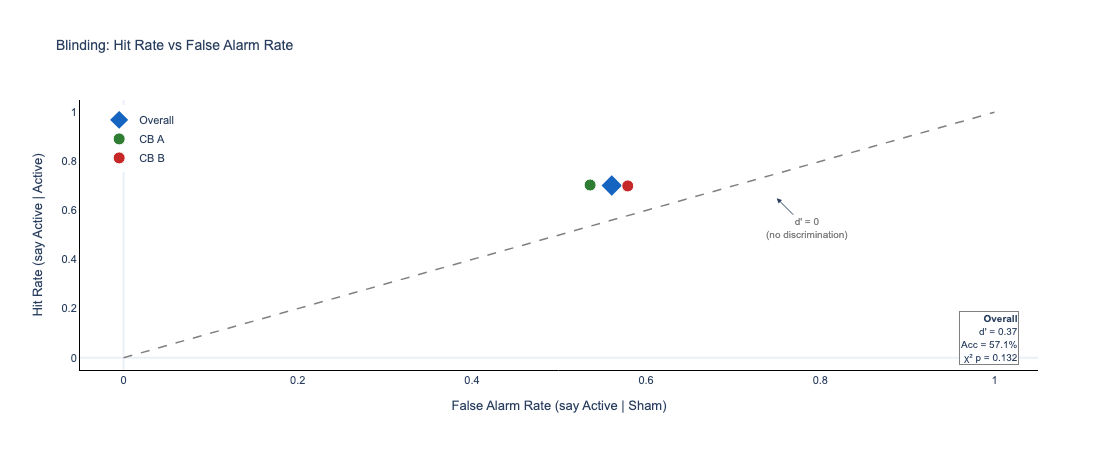


✓ Blinding appears intact


In [14]:
# Signal detection analysis of blinding
blinding_results = run_blinding_analysis(data_clean)

if blinding_results['blinding_intact']:
    print('\n✓ Blinding appears intact')
else:
    print('\n⚠ Blinding may be compromised — interpret with caution')

---
## 4. Win-Stay / Lose-Shift Analysis

H1 WSLS (sham, clean runs):
subject_id  p_stay_win  p_shift_lose  n_win_trials  n_lose_trials  n_total_trials
     10369    0.591549      0.507692            71             65             136
     10418    0.959459      0.500000            74             68             142
     10541    0.945946      0.648148            74             54             128
     10559    0.881579      0.353846            76             65             141
     10589    0.913462      0.369565           104             46             150
     10590    0.763158      0.537313            76             67             143
     10606    0.439024      0.470588            41             34              75
     10608    0.976744      0.677966            86             59             145
     10636    0.989796      0.395833            98             48             146
     10638    0.459459      0.420290            74             69             143
     10641    0.873418      0.606557            79             61     

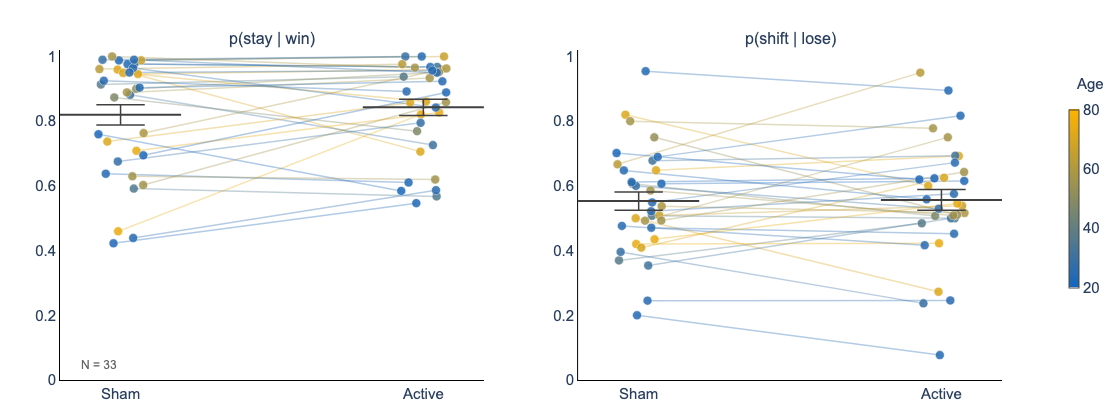

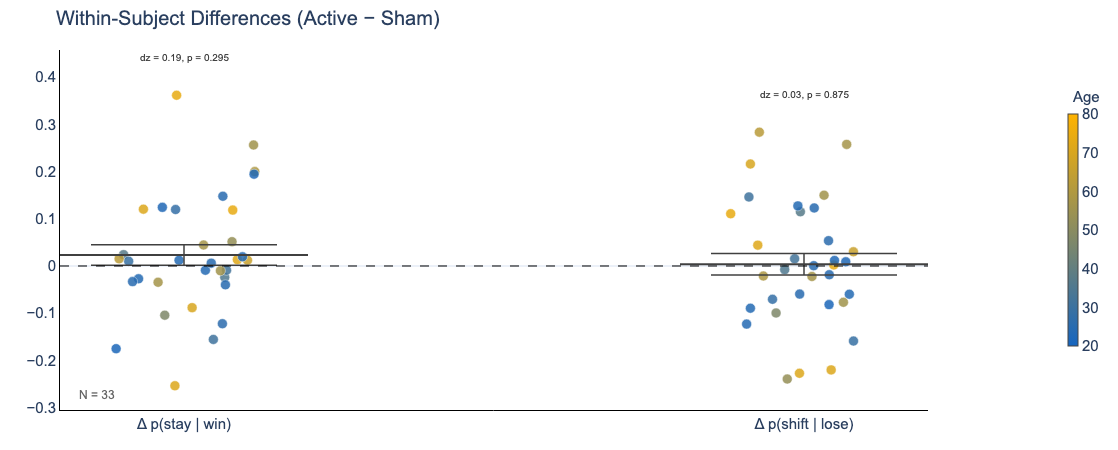

In [17]:
# WSLS analysis for H1 and H2
wsls_results = run_wsls_analysis(data_h1, data_h2, data)

---
## 5. Reversal Learning Analysis

Identified 578 reversals across 36 subjects
Trials in reversal windows: 12037 / 21327

Reversals per subject × condition:
condition   active  baseline  post  sham
subject_id                              
10369            4         4     4     4
10418            4         4     4     4
10541            4         4     4     4
10559            4         4     4     4
10589            4         4     4     4
10590            4         4     4     4
10606            4         4     4     4
10608            4         4     4     4
10636            4         4     4     4
10638            4         4     4     4
10641            4         4     4     4
10649            4         4     4     4
10656            4         4     4     4
10661            4         4     4     4
10716            4         4     5     4
10804            4         4     4     4
10809            4         4     4     4
10810            4         4     4     4
10862            4         4     4     4
10866            

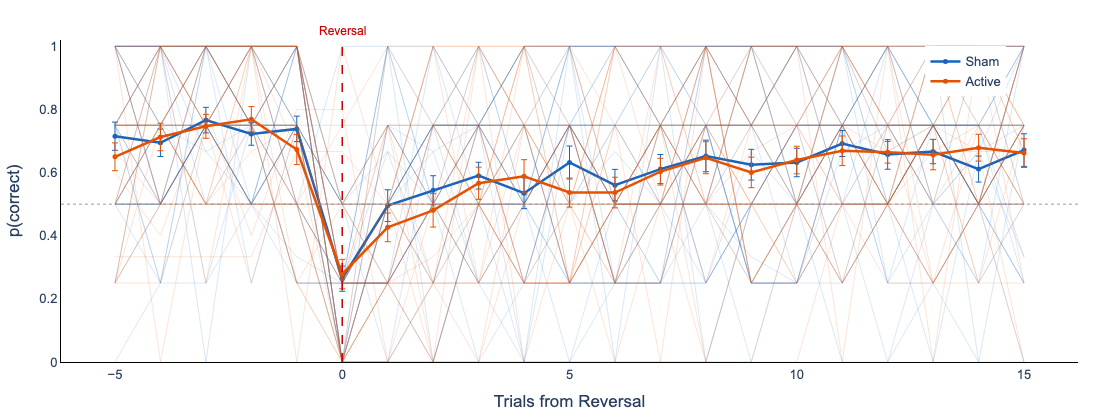

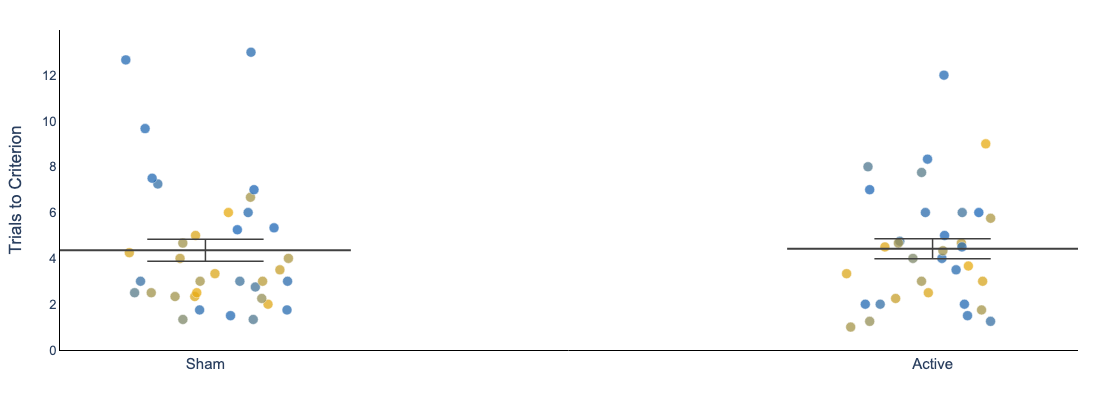

In [20]:
# Reversal-locked accuracy and trials to criterion
rev_results = run_reversal_analysis(data, data_clean, conditions=['sham', 'active'])

---
## 6. Rescorla-Wagner Model

In [23]:
# Fit R-W model (MLE and MAP)
rw_results = run_rw_analysis(
    data_clean, 
    h2_subjects=h2_eligible,
    run_recovery=False  # Set True to run parameter recovery (slow)
)


Rescorla-Wagner Model Fitting

Fitted 70 subject × condition blocks

⚠ WARNING: 23 fits hit parameter boundaries

MLE vs MAP correlation: α = 0.896, β = 0.656

Subject-level fits: 36 subjects
  α: M = 0.663, SD = 0.364
  β: M = 3.99, SD = 7.23

--------------------------------------------------
Paired Comparison (H2 subjects)
--------------------------------------------------
  alpha: Δ = +0.029, dz = 0.08, t(32) = 0.45, p = 0.6553
  beta: Δ = -0.121, dz = -0.02, t(32) = -0.10, p = 0.9243


---
## 7. Drift Diffusion Model

In [26]:
# Fit DDM (requires pyddm)
ddm_results = run_ddm_analysis(
    data_clean,
    conditions=['sham', 'active'],
    run_bootstrap=False,  # Set True for bootstrap CI (slow)
    n_bootstrap=200
)

Drift Diffusion Model Analysis

DDM data preparation:
  Retained: 19705 trials (97.6%)
  Excluded: 494 trials
  Participants: 36
  Conditions: ['baseline', 'sham', 'active']

RT distribution (seconds):
  Mean: 0.619, Median: 0.531
  SD: 0.299

Overall accuracy: 64.3%

--------------------------------------------------
Condition-Level DDM Fits
--------------------------------------------------
  Fitting sham condition (n=4804 trials)...


Info: Params [0.28637849 0.77052806 0.20898116] gave 36321.163720860786


    v = 0.286, a = 0.771, t = 0.209s
  Fitting active condition (n=4855 trials)...


Info: Params [0.31664961 0.78958336 0.18450083] gave 38404.86444829408


    v = 0.317, a = 0.790, t = 0.185s

--------------------------------------------------
Condition Comparison
--------------------------------------------------
  v: sham = 0.286, active = 0.317, Δ = +0.030
  a: sham = 0.771, active = 0.790, Δ = +0.019
  t: sham = 0.209, active = 0.185, Δ = -0.024

--------------------------------------------------
Subject-Level DDM Fits
--------------------------------------------------


...

  Processing subject 30/36


Info: Params [0.45447619 0.69419922 0.26851365] gave 1226.7258016846379
Info: Params [0.37022325 0.72179946 0.27505322] gave 1139.6834128616397
Info: Params [0.41304824 0.72028265 0.28301671] gave 1190.274894519979
Info: Params [0.35712912 0.73831014 0.23259812] gave 604.8176978044456
Info: Params [0.19308542 0.64712974 0.25203343] gave 848.7085000869025
Info: Params [0.134019   0.65463444 0.23211953] gave 790.5762861139499
Info: Params [0.30452118 0.71339837 0.21569793] gave 1118.6039703715874
Info: Params [0.55439562 0.68570015 0.18631926] gave 1349.4905710269018
Info: Params [0.4312311  0.6885468  0.24150524] gave 1214.1392577557606
Info: Params [0.28836851 0.64746462 0.33968221] gave 963.2058427800891


  Processing subject 35/36


Info: Params [0.26189834 0.70380186 0.37039988] gave 946.7297688589539
Info: Params [0.28714676 0.74634422 0.31513937] gave 1067.8274492506187
Info: Params [0.38487647 0.77599915 0.14583002] gave 1184.664595369514
Info: Params [0.44605491 0.65296343 0.1424391 ] gave 381.008508615983



  Complete cases (both conditions): 34

  V: Δ = +0.031, dz = 0.25, t = 1.46, p = 0.154

  A: Δ = -0.000, dz = -0.01, t = -0.04, p = 0.965

  T: Δ = -0.008, dz = -0.17, t = -1.01, p = 0.318


---
## 8. EEG Theta Reactivity

Theta Reactivity Analysis (Baseline Runs)

Computing theta reactivity...
  Sub-10998 Run 5: θ_p95 = 209.4%
  Sub-11773 Run 1: θ_p95 = 362.7%
  Sub-11773 Run 5: θ_p95 = 327.2%
  Sub-10886 Run 1: θ_p95 = 201.1%
  Sub-10886 Run 5: θ_p95 = 197.0%
  Sub-10656 Run 1: θ_p95 = 207.5%
  Sub-10656 Run 5: θ_p95 = 210.7%
  Sub-10951 Run 1: θ_p95 = -90.5%
  Sub-10951 Run 5: θ_p95 = 263.8%
  Sub-10418 Run 1: θ_p95 = 205.9%
  Sub-10418 Run 5: θ_p95 = 215.2%
  Sub-10636 Run 1: θ_p95 = 143.0%
  Sub-10636 Run 5: θ_p95 = 274.4%
  Sub-11318 Run 1: θ_p95 = 283.1%
  Sub-11318 Run 5: θ_p95 = 292.8%
  Sub-10369 Run 1: θ_p95 = 301.5%
  Sub-10369 Run 5: θ_p95 = 243.2%
  Sub-10606 Run 1: θ_p95 = 244.8%
  Sub-10606 Run 5: θ_p95 = 127.9%
  Sub-11628 Run 1: θ_p95 = 218.4%
  Sub-11628 Run 5: θ_p95 = 234.2%
  Sub-11286 Run 1: θ_p95 = 221.2%
  Sub-11286 Run 5: θ_p95 = 224.4%
  Sub-10866 Run 1: θ_p95 = 229.6%
  Sub-10866 Run 5: θ_p95 = 209.6%
  Sub-11329 Run 1: θ_p95 = 282.7%
  Sub-11329 Run 5: θ_p95 = 255.1%
  Sub-106

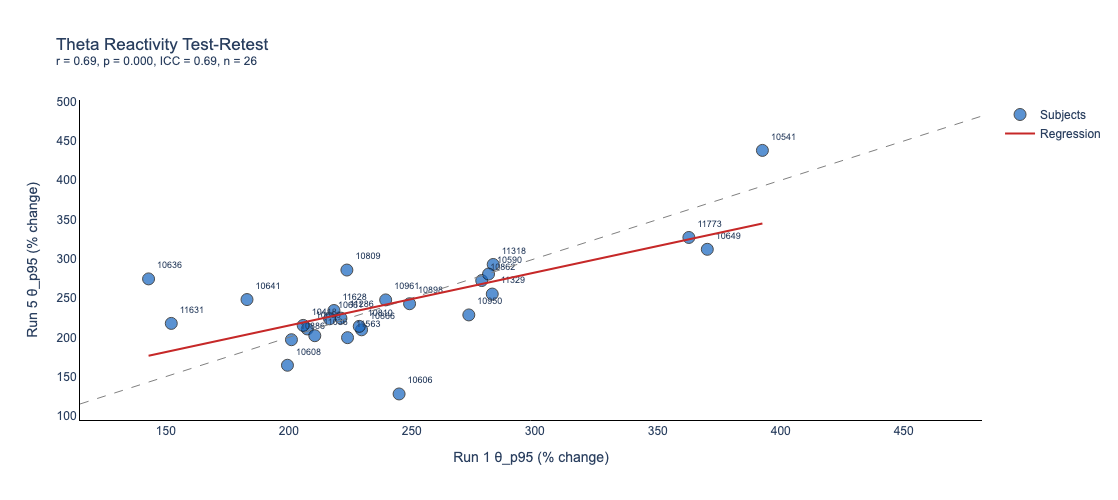

Insufficient data for age plot

Theta reliability (ICC): 0.689


In [29]:
# Compute theta reactivity from baseline EEG (F4 channel)
# Note: Requires EEG .easy files in DATA_DIR/nic/raw
try:
    theta_results = run_theta_analysis(verbose=True, show_plots=True)
    theta_subject = theta_results.get('theta_subject')
    print(f'\nTheta reliability (ICC): {theta_results["reliability"]["ICC"]:.3f}')
except FileNotFoundError:
    print('EEG files not found - skipping theta analysis')
    theta_results = None
    theta_subject = None

---
## 9. Cognitive & Survey Data Integration

In [32]:
# Load external data and build subject DataFrame
cog_results = run_cognitive_merge(
    wsls_h1=wsls_results.get('wsls_h1'),
    wsls_h2=wsls_results.get('wsls_h2'),
    rw_mle=rw_results.get('rw_mle'),
    ddm_params=ddm_results.get('ddm_subject') if ddm_results else None,
    theta_subject=theta_subject,
    h2_subjects=h2_eligible
)

subj_df = cog_results['subj_df']
print(f'\nSubject DataFrame: {len(subj_df)} subjects, {len(subj_df.columns)} variables')
if 'theta_p95' in subj_df.columns:
    print(f'Subjects with theta data: {subj_df["theta_p95"].notna().sum()}')

Loading External Data Sources
  RF1 FullScoring: 37 subjects
  RF1 Raw: 37 subjects
  TabCAT: 36 subjects
  tACS REDCap: 37 subjects

--------------------------------------------------
Computing Cognitive Composites
--------------------------------------------------
  attention_composite: 36/37 with data
  memory_composite: 37/37 with data
  speed_composite: 37/37 with data
  global_composite: 37/37 with data
  ef_composite: 36/37 with data

--------------------------------------------------
Building Subject DataFrame
--------------------------------------------------
  Theta reactivity: 32
Subject DataFrame assembled: 37 subjects, 38 variables
  Cognitive composites: 37
  WSLS (sham): 36
  R-W (sham): 36

Subject DataFrame: 37 subjects, 38 variables
Subjects with theta data: 32


---
## 9b. Extended Computational Models (Exploratory)

This section implements more sophisticated RL models to test hypotheses about **confirmation bias**, **perseveration**, and **value differentiation** in aging and tACS effects.

### Models
1. **Asymmetric R-W** (α⁺, α⁻, β): Separate learning rates for positive vs. negative prediction errors
2. **Asymmetric R-W + Stickiness** (α⁺, α⁻, β, τ): Adds perseveration independent of learned values
3. **Standard R-W + Stickiness** (α, β, τ): For model comparison

### Key Parameters
| Parameter | Interpretation |
|-----------|---------------|
| α⁺ | Learning rate for positive prediction errors (confirmatory feedback) |
| α⁻ | Learning rate for negative prediction errors (disconfirmatory feedback) |
| α⁺/α⁻ | Confirmation bias index (>1 = learns more from rewards than losses) |
| τ | Choice stickiness (>0 = perseveration, tendency to repeat regardless of value) |
| β | Inverse temperature / value differentiation |

### Hypotheses Tested
- **H-RL1**: Older adults show elevated α⁺/α⁻ ratios (confirmation bias)
- **H-RL2**: α⁺/α⁻ correlates with WSLS patterns (computational ↔ behavioral link)
- **H-RL5**: β declines with age (reduced value differentiation)
- **H-RL7**: Older adults show elevated τ (perseveration)
- **H-RL8**: τ correlates with poorer executive function

*Note: These analyses are exploratory extensions beyond the pre-registered hypotheses.*

In [ ]:
# Import extended R-W module
from rescorla_wagner_extended import run_extended_rw_analysis

In [ ]:
# Run extended R-W analysis
# Uses data_clean for model fitting, subj_df for age/cognitive correlates
# Includes outlier diagnostics and sensitivity analysis

extended_rw_results = run_extended_rw_analysis(
    data=data_clean,
    subj_df=subj_df,
    wsls_df=wsls_results['wsls_h1'],  # For H-RL2: α⁺/α⁻ × WSLS correlations
    standard_rw_df=rw_results['rw_mle'],  # For model comparison with original R-W
    conditions=['sham', 'active'],
    method='mle',
    show_plots=True,
    verbose=True
)

In [ ]:
# Extract key results
extended_model_fits = extended_rw_results['model_fits']
extended_comparison = extended_rw_results['comparison']
extended_tests = extended_rw_results['hypothesis_tests']
sensitivity = extended_rw_results['sensitivity']

# Summary: Best model by subject
if 'best_model' in extended_comparison.columns:
    print("\nBest-fitting model distribution:")
    print(extended_comparison['best_model'].value_counts())

---
## 10. Pre-Registered Hypothesis Tests

In [ ]:
# Run all H1 and H2 tests
hyp_results = run_hypothesis_tests(subj_df, show_plots=True)

---
## 11. Order & Session Effects

In [35]:
# Check for counterbalance confounds
order_results = run_order_effects_analysis(subj_df)

Sample by Counterbalance Order:
----------------------------------------
  Order A (Active first): n = 15
  Order B (Sham first): n = 22

WSLS/RW Parameters by Order and Condition:
----------------------------------------------------------------------

p(stay|win):
  Order A / Sham  : M = 0.847, SD = 0.210 (n=15)
  Order B / Sham  : M = 0.811, SD = 0.144 (n=21)
  Order A / Active: M = 0.845, SD = 0.160 (n=14)
  Order B / Active: M = 0.841, SD = 0.137 (n=19)

p(shift|lose):
  Order A / Sham  : M = 0.519, SD = 0.195 (n=15)
  Order B / Sham  : M = 0.554, SD = 0.142 (n=21)
  Order A / Active: M = 0.576, SD = 0.188 (n=14)
  Order B / Active: M = 0.542, SD = 0.184 (n=19)

α:
  Order A / Sham  : M = 0.571, SD = 0.431 (n=15)
  Order B / Sham  : M = 0.645, SD = 0.377 (n=21)
  Order A / Active: M = 0.688, SD = 0.370 (n=14)
  Order B / Active: M = 0.631, SD = 0.367 (n=19)

β:
  Order A / Sham  : M = 5.482, SD = 3.663 (n=15)
  Order B / Sham  : M = 5.303, SD = 9.654 (n=21)
  Order A / Active: M = 

---
## 12. Correlation Matrix


Variables included: 16 total
  Primary: 12
  Secondary: 4

Pairwise sample sizes (min/max):
  Min N: 14
  Max N: 37
  Median N: 35

Significant correlations (p < .05): 21
  Attention × Exec. Func.: r = 0.933, p = 0.0000
  Global Cog. × Proc. Speed: r = 0.823, p = 0.0000
  Global Cog. × Ep. Memory: r = 0.746, p = 0.0000
  Global Cog. × Attention: r = 0.725, p = 0.0000
  Age × Attention: r = -0.674, p = 0.0000
  Global Cog. × Exec. Func.: r = 0.667, p = 0.0000
  p(stay|win) × α (learn rate): r = 0.656, p = 0.0000
  SPSRQ-SP × SCD-Q: r = 0.740, p = 0.0000
  Age × Exec. Func.: r = -0.617, p = 0.0001
  Attention × Proc. Speed: r = 0.575, p = 0.0002
  ... and 11 more


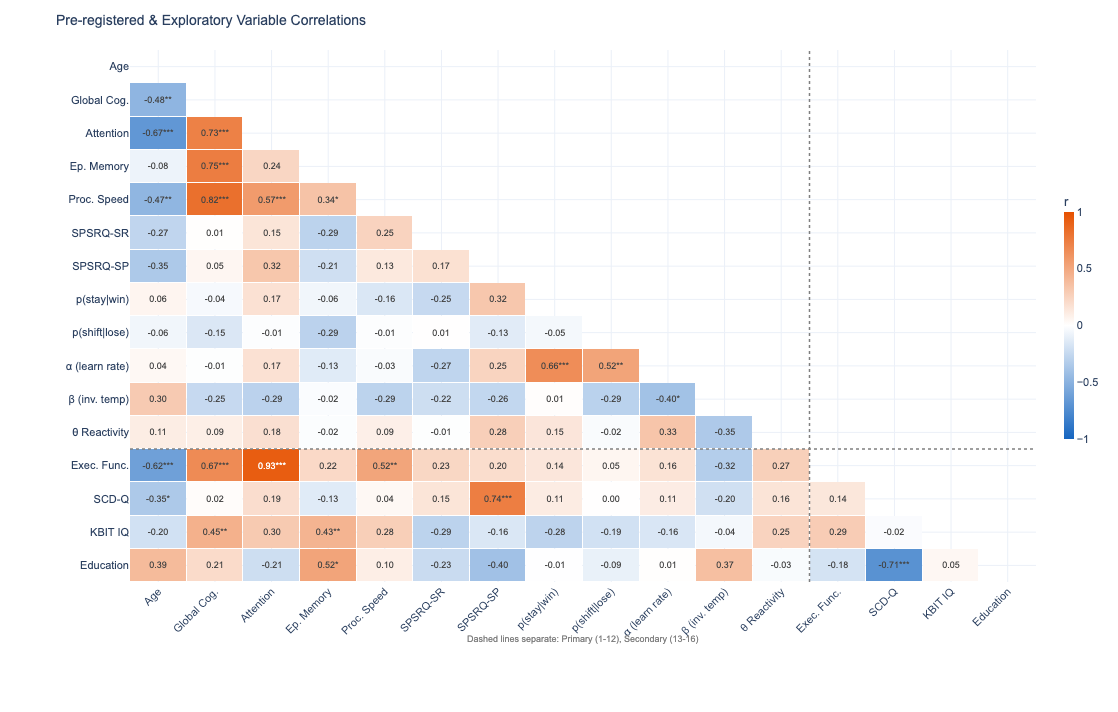

In [38]:
# Pairwise correlations among pre-registered variables
# (now includes theta_p95)
corr_results = run_correlation_analysis(subj_df, include_tertiary=False)

---
## 13. Summary

In [41]:
print('='*70)
print('ANALYSIS SUMMARY')
print('='*70)
print()

# Sample
print(f'Sample: N = {len(subj_df)}')
print(f'  H1-eligible (sham): {data_h1["subject_id"].nunique()}')
print(f'  H2-eligible (paired): {len(h2_eligible)}')
if 'theta_p95' in subj_df.columns:
    print(f'  With theta data: {subj_df["theta_p95"].notna().sum()}')
print()

# Blinding
if blinding_results['blinding_intact']:
    print('✓ Blinding intact')
else:
    print('⚠ Blinding concern')

# Order effects
if order_results['any_significant_order']:
    print('⚠ Significant order × condition interaction')
else:
    print('✓ No significant order effects')

# Theta reliability
if theta_results is not None and 'reliability' in theta_results:
    icc = theta_results['reliability'].get('ICC', np.nan)
    if not np.isnan(icc):
        if icc >= 0.75:
            print(f'✓ Theta reliability excellent (ICC = {icc:.2f})')
        elif icc >= 0.60:
            print(f'✓ Theta reliability good (ICC = {icc:.2f})')
        else:
            print(f'⚠ Theta reliability fair/poor (ICC = {icc:.2f})')

# Extended RL model comparison
if 'best_model' in extended_comparison.columns:
    best = extended_comparison['best_model'].value_counts().idxmax()
    pct = 100 * extended_comparison['best_model'].value_counts().max() / len(extended_comparison)
    print(f'✓ Best-fitting model: {best} ({pct:.0f}% of fits)')
print()

# H2.1 summary
print('H2.1 Paired Comparisons (tACS vs. Sham):')
for param, res in hyp_results['h2_1'].items():
    if res is not None:
        sig = '*' if res['p'] < 0.05 else ''
        print(f"  {param}: dz = {res['dz']:.3f}, p = {res['p']:.3f} {sig}")

ANALYSIS SUMMARY

Sample: N = 37
  H1-eligible (sham): 36
  H2-eligible (paired): 33
  With theta data: 32

✓ Blinding intact
✓ No significant order effects
✓ Theta reliability good (ICC = 0.69)


NameError: name 'extended_comparison' is not defined

---
## 14. Accuracy & Win Rate Analysis

Examines task performance metrics:
- **Run-level accuracy**: Performance across the 8 runs
- **Counterbalance effects**: Does order (sham-first vs active-first) matter?
- **Stimulation effects**: Does tACS affect accuracy or win rate?
- **Learning curves**: Within-run and within-contingency learning
- **Age effects**: Does accuracy decline with age?

In [44]:
# Import accuracy analysis module
from accuracy_analysis import run_accuracy_analysis

ACCURACY ANALYSIS
RUN-LEVEL ACCURACY SUMMARY

Total runs: 272
Subjects: 36

Overall accuracy: M = 0.642, SD = 0.111
Overall win rate: M = 0.570, SD = 0.078

Runs above chance (>50%): 247 / 272 (90.8%)
Runs near optimal (>=70%): 80 / 272 (29.4%)

CONDITION-LEVEL ACCURACY SUMMARY

SHAM:
  N = 36
  Accuracy: M = 0.643, SD = 0.097
  Win rate: M = 0.568, SD = 0.056

ACTIVE:
  N = 34
  Accuracy: M = 0.626, SD = 0.102
  Win rate: M = 0.558, SD = 0.063

COUNTERBALANCE EFFECTS ANALYSIS

Overall Accuracy by Counterbalance:
  A (sham first): M = 0.636, SD = 0.070, n = 15
  B (active first): M = 0.643, SD = 0.079, n = 21
  t = -0.26, p = 0.795, d = -0.09

Practice Effect (2nd half - 1st half) by Counterbalance:
  A: Δ = +0.038
  B: Δ = +0.027
  t = 0.37, p = 0.714

Sham Accuracy by Order:
  Sham first (CB=A): M = 0.666
  Sham second (CB=B): M = 0.625
  t = 1.26, p = 0.215

Active Accuracy by Order:
  Active first (CB=B): M = 0.645
  Active second (CB=A): M = 0.599
  t = 1.32, p = 0.197

STIMULATIO

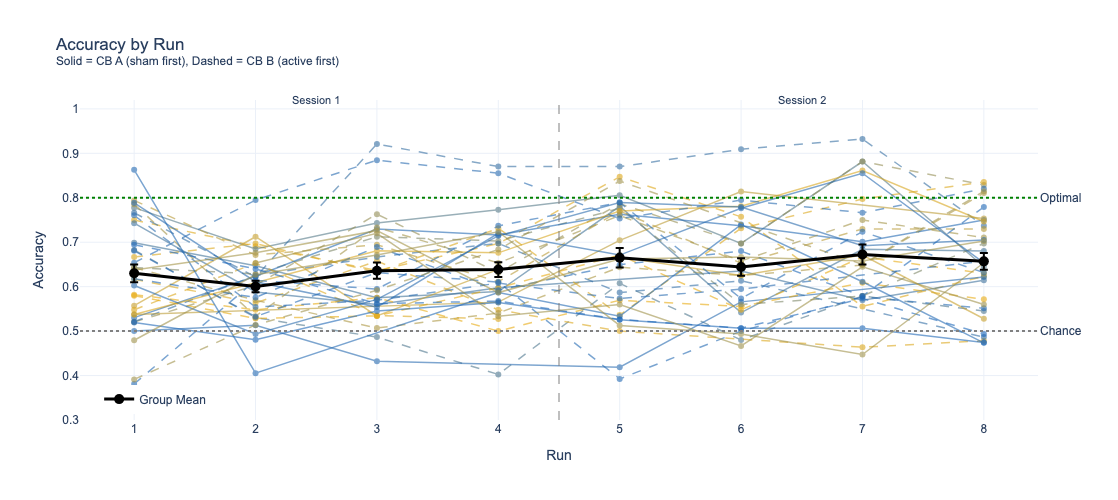

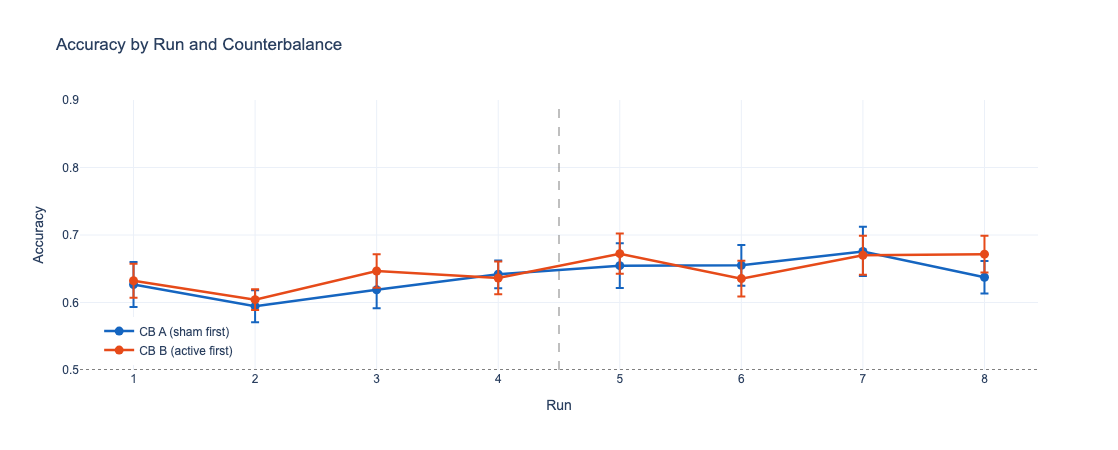

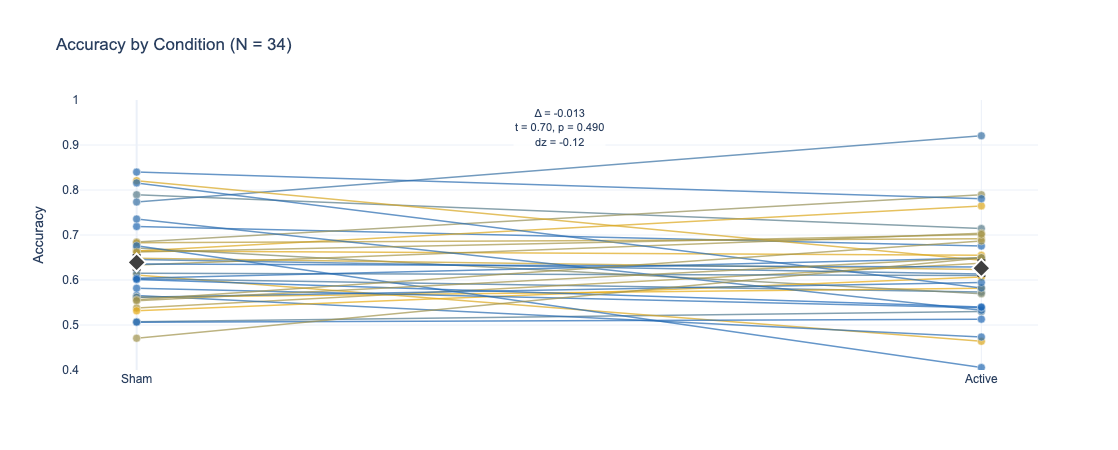

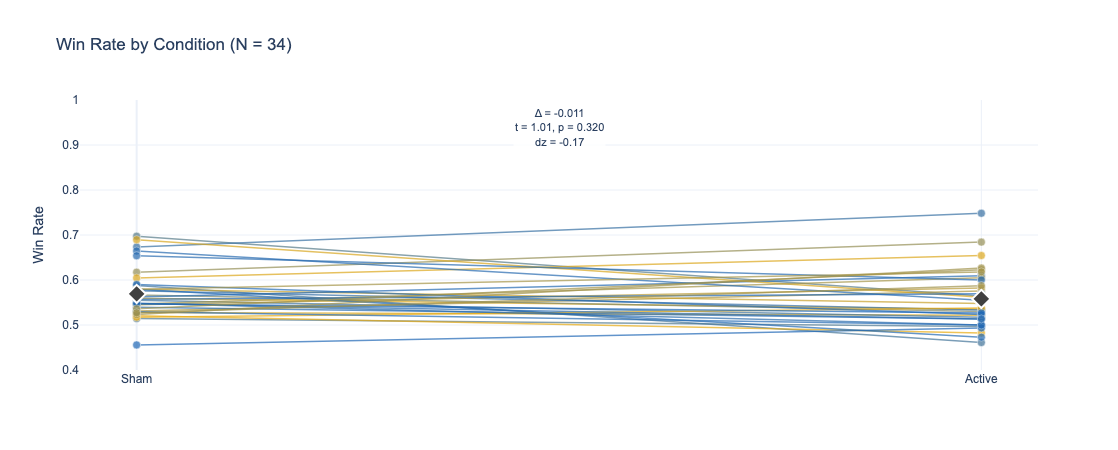

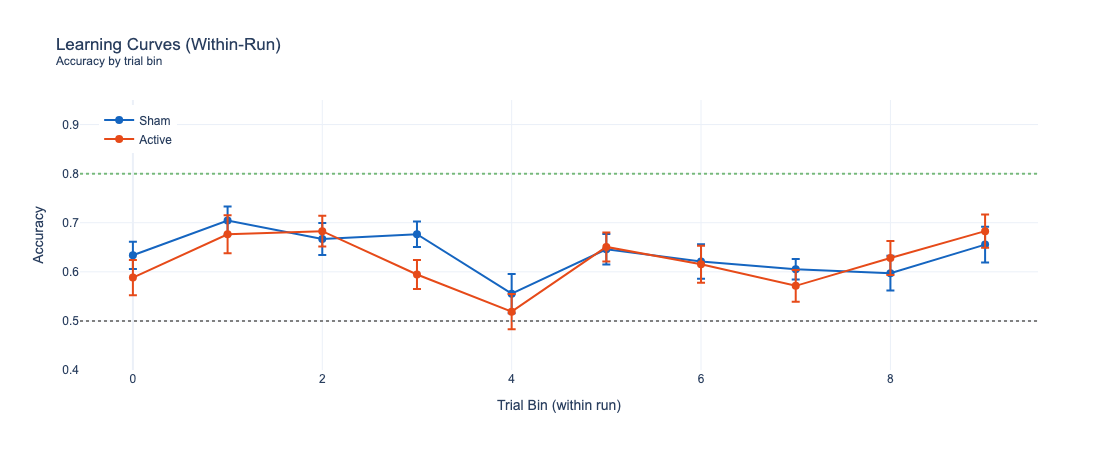

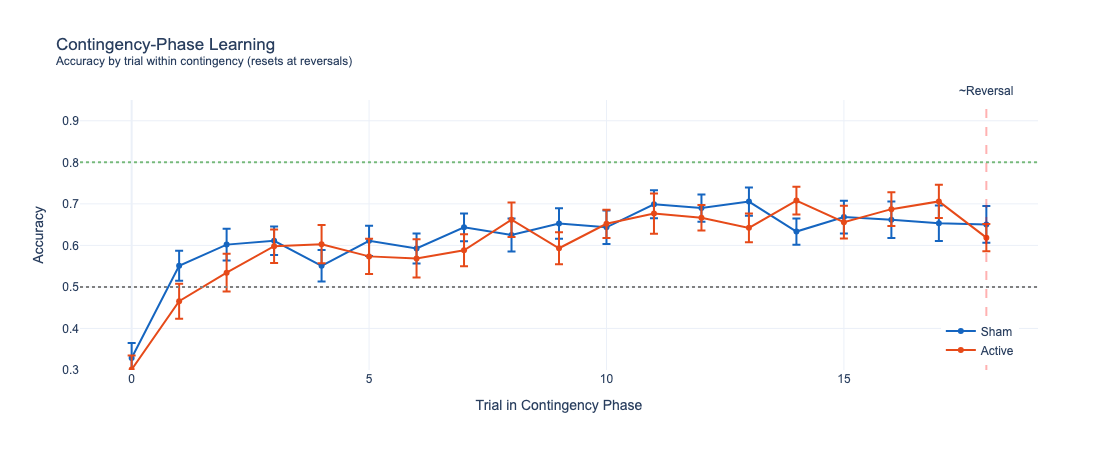

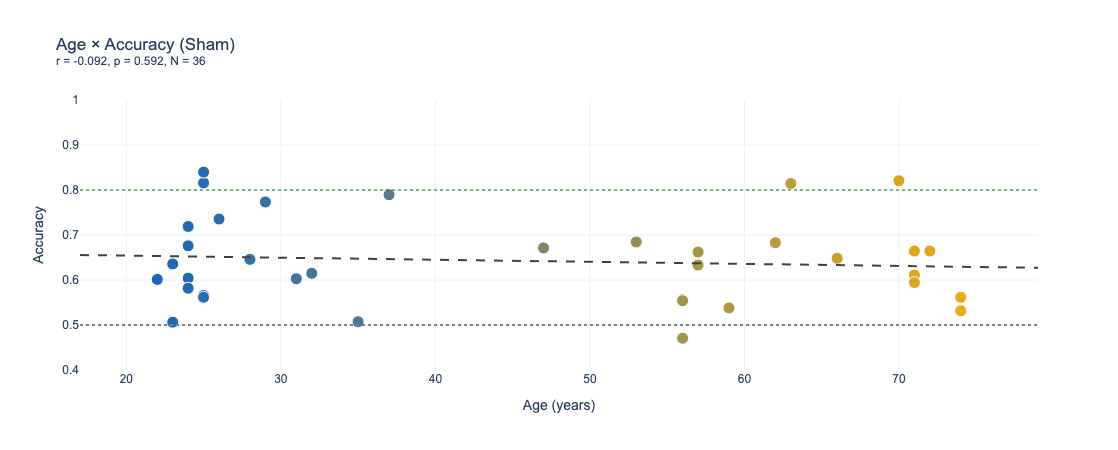

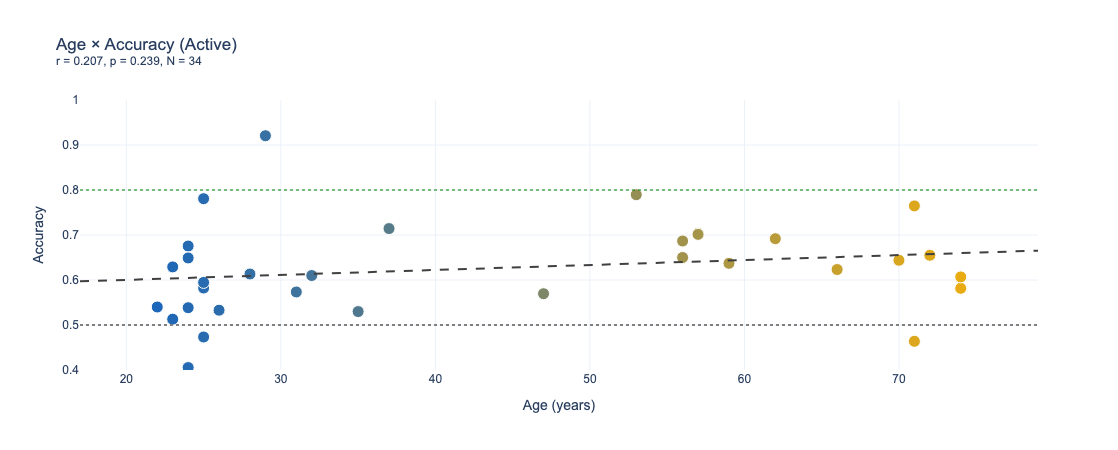

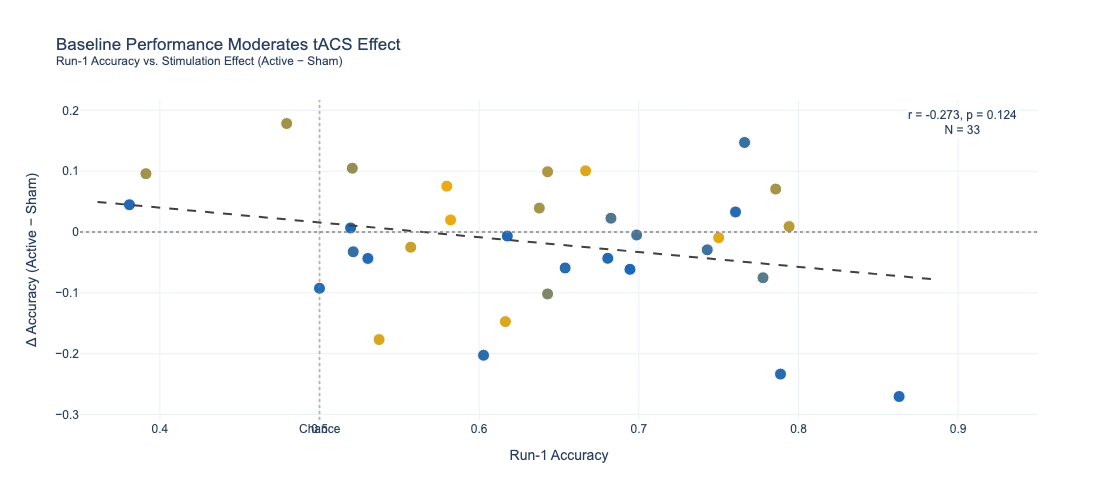

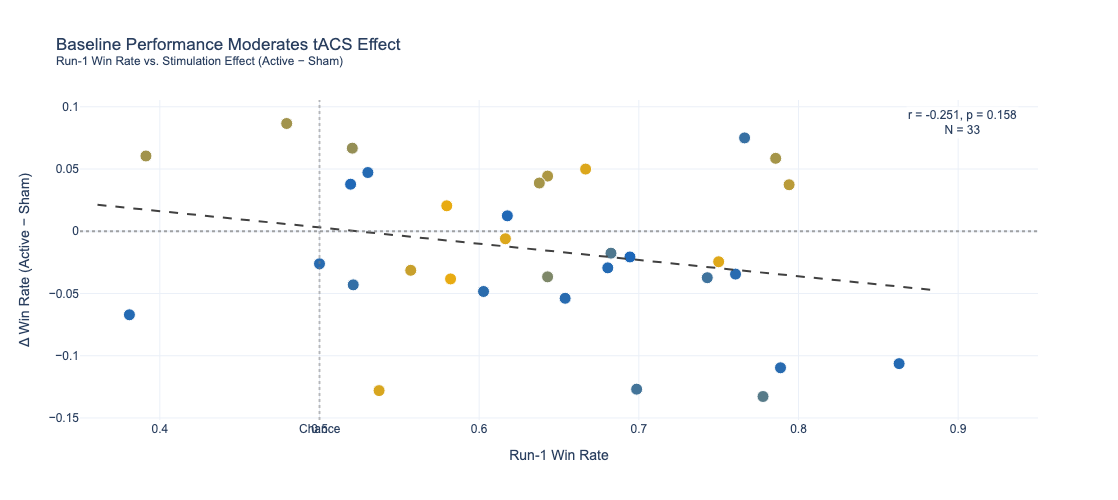


ACCURACY ANALYSIS COMPLETE


In [46]:
# Run complete accuracy analysis
acc_results = run_accuracy_analysis(
    data=data_clean,
    conditions=['sham', 'active'],
    show_plots=True,
    verbose=True
)

In [48]:
# Extract key results for reference
run_level_acc = acc_results['run_level']
cond_level_acc = acc_results['condition_level']
cb_effects = acc_results['counterbalance']
stim_effects_acc = acc_results['stimulation_effects']
age_effects_acc = acc_results['age_effects']

# Quick summary
print("\nStimulation effect on accuracy:")
if 'accuracy' in stim_effects_acc:
    r = stim_effects_acc['accuracy']
    sig = '*' if r['p'] < 0.05 else ''
    print(f"  Sham: {r['sham_mean']:.3f}, Active: {r['active_mean']:.3f}, p = {r['p']:.3f}{sig}")

print("\nStimulation effect on win rate:")
if 'win_rate' in stim_effects_acc:
    r = stim_effects_acc['win_rate']
    sig = '*' if r['p'] < 0.05 else ''
    print(f"  Sham: {r['sham_mean']:.3f}, Active: {r['active_mean']:.3f}, p = {r['p']:.3f}{sig}")


Stimulation effect on accuracy:
  Sham: 0.639, Active: 0.626, p = 0.490

Stimulation effect on win rate:
  Sham: 0.569, Active: 0.558, p = 0.320


---
## 15. Electric Field Analysis

Analyzes simulated electric field strength in the target ROI (left DLPFC / F3):
- **Age × E-field**: Does cortical atrophy reduce field strength in older adults?
- **E-field moderation**: Does stronger e-field predict larger tACS effects?

In [51]:
# Import e-field analysis module
from efield_analysis import run_efield_analysis

E-FIELD ANALYSIS
E-FIELD DATA SUMMARY

Subjects with e-field data: 35
Subjects in SUBJECT_INFO: 37
Overlap: 35
Missing e-field data: [10951, 11036]

mean_magnE (V/m):
  Mean: 0.2287
  SD: 0.0664
  Range: 0.1105 - 0.3706

Subjects with age data: 34
Age range: 22 - 74

AGE × E-FIELD RELATIONSHIP

Pearson r = -0.392, p = 0.022*
Spearman ρ = -0.387, p = 0.024
N = 34

Interpretation: Older adults show weaker e-fields

E-FIELD MODERATION OF STIMULATION EFFECTS

Question: Does e-field strength predict tACS efficacy?
Test: Δ(active - sham) ~ mean_magnE

DV                               r          p     n   sig
-------------------------------------------------------
accuracy                    -0.047      0.799    32      
win_rate                     0.017      0.926    32      
wsls_p_shift_lose           -0.007      0.968    31      
wsls_p_stay_win              0.056      0.763    31      

GENERATING VISUALIZATIONS


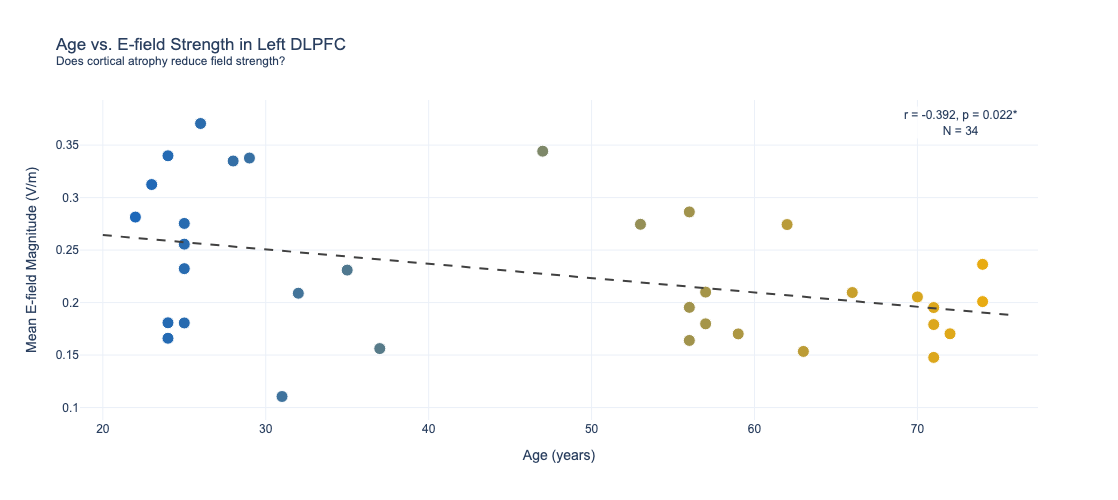

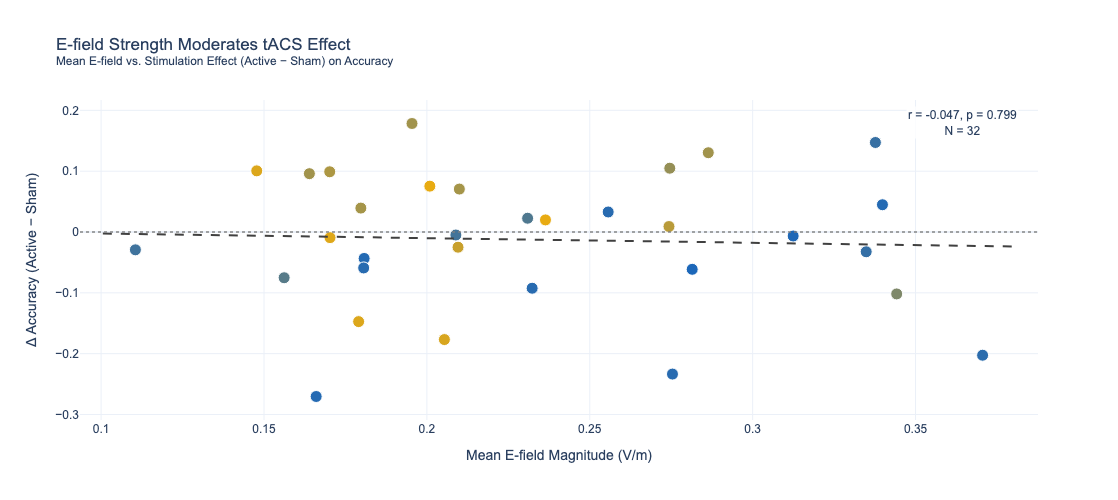

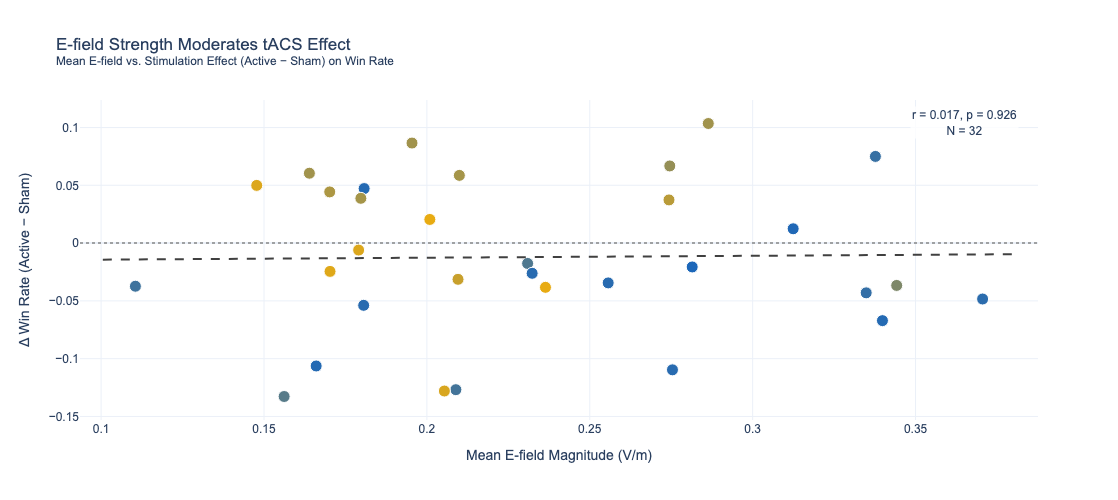

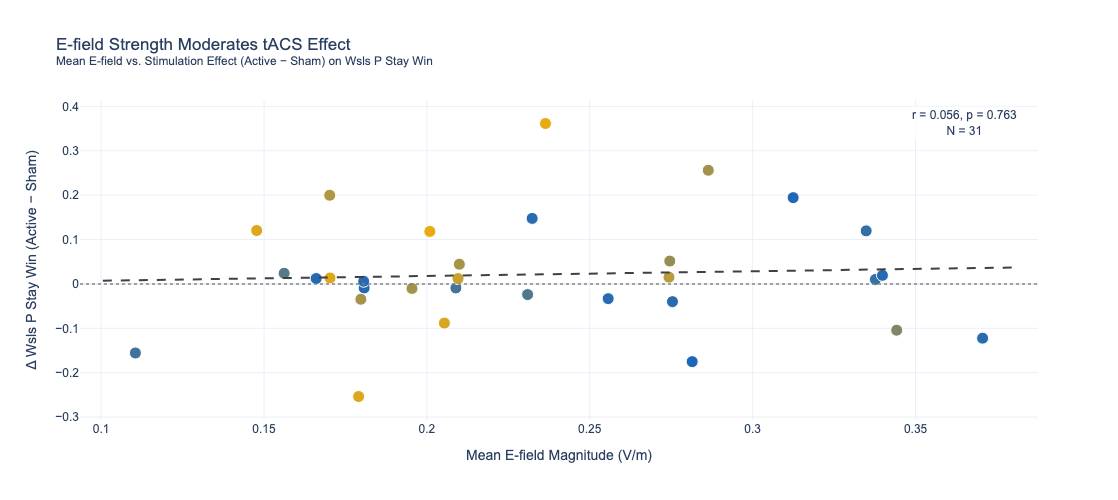

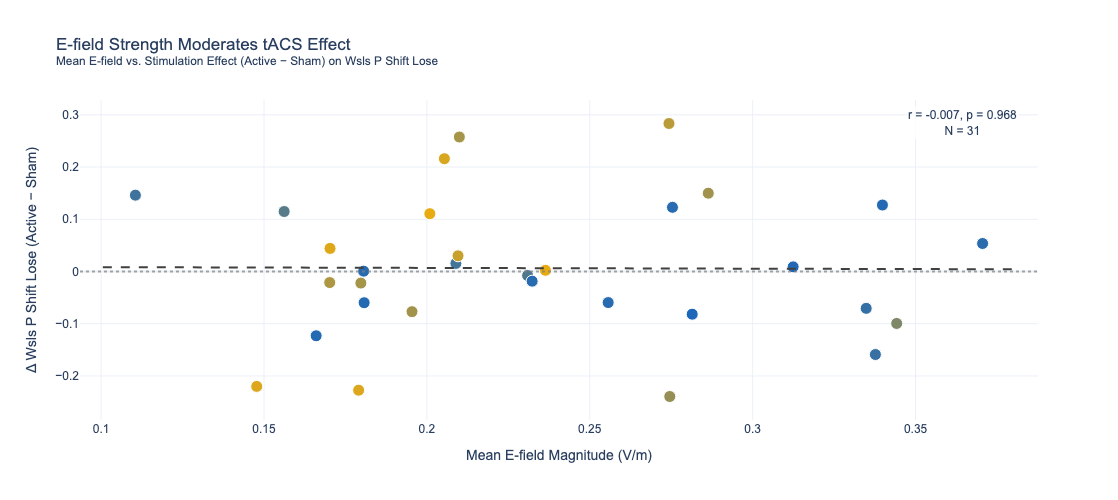

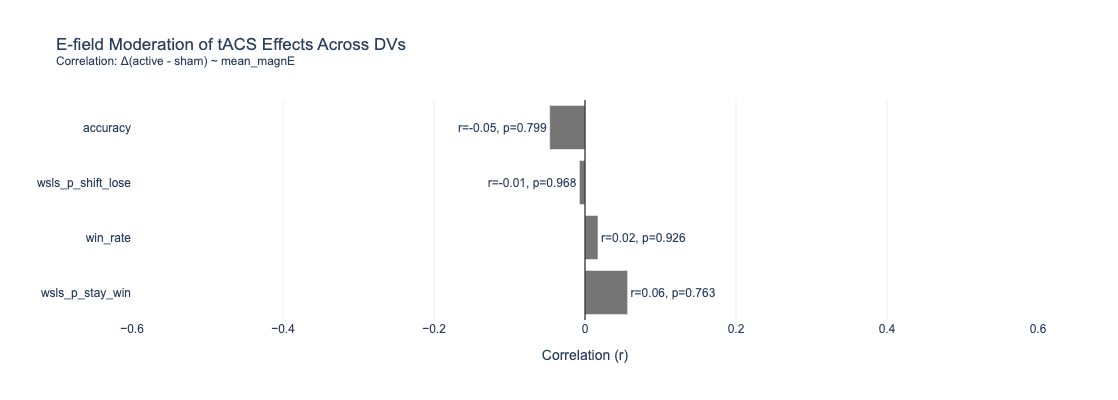


E-FIELD ANALYSIS COMPLETE


In [53]:
# Run e-field analysis
# Requires: efield_roi_summary.csv in working directory

efield_results = run_efield_analysis(
    efield_path='efield_roi_summary.csv',
    cond_df=acc_results['condition_level'],
    wsls_h2=wsls_results.get('wsls_h2'),
    rw_df=rw_results.get('rw_mle'),
    ddm_df=ddm_results.get('ddm_subject') if ddm_results else None,
    show_plots=True,
    verbose=True
)

In [55]:
# Extract key results
efield_df = efield_results['efield_data']
age_efield = efield_results['age_relationship']
efield_moderation = efield_results['moderation']

# Summary
print("\nE-field Analysis Summary:")
print(f"  Subjects with e-field data: {len(efield_df)}")

if age_efield:
    sig = '*' if age_efield['p'] < 0.05 else ''
    print(f"  Age × E-field: r = {age_efield['r']:.3f}, p = {age_efield['p']:.3f}{sig}")

print("\n  E-field moderation of Δ(active - sham):")
for dv, res in efield_moderation.items():
    sig = '*' if res['p'] < 0.05 else ''
    print(f"    {dv}: r = {res['r']:.3f}, p = {res['p']:.3f}{sig}")


E-field Analysis Summary:
  Subjects with e-field data: 35
  Age × E-field: r = -0.392, p = 0.022*

  E-field moderation of Δ(active - sham):
    accuracy: r = -0.047, p = 0.799
    win_rate: r = 0.017, p = 0.926
    wsls_p_stay_win: r = 0.056, p = 0.763
    wsls_p_shift_lose: r = -0.007, p = 0.968


In [57]:
print("wsls_h2 columns:", wsls_results.get('wsls_h2').columns.tolist())
print("wsls_h2 head:")
print(wsls_results.get('wsls_h2').head())

wsls_h2 columns: ['subject_id', 'condition', 'p_stay_win', 'p_shift_lose', 'n_win_trials', 'n_lose_trials', 'n_total_trials']
wsls_h2 head:
  subject_id condition  p_stay_win  p_shift_lose  n_win_trials  n_lose_trials  \
0      10369    active    0.567568      0.500000            74             74   
1      10369      sham    0.591549      0.507692            71             65   
2      10418    active    0.705882      0.272727            34             33   
3      10418      sham    0.959459      0.500000            74             68   
4      10541    active    0.959459      0.692308            74             65   

   n_total_trials  
0             148  
1             136  
2              67  
3             142  
4             139  


---
## Module Reference

| Module | Purpose |
|--------|--------|
| `config.py` | Paths, SUBJECT_INFO, colors, constants |
| `data_loading.py` | Load and preprocess behavioral data |
| `exclusions.py` | Apply behavioral and stim exclusion criteria |
| `sample_descriptives.py` | Demographics, age distribution, cap size |
| `blinding_analysis.py` | Signal detection analysis of blinding |
| `wsls.py` | Win-stay/lose-shift analysis |
| `reversal_analysis.py` | Reversal-locked accuracy curves |
| `rescorla_wagner.py` | R-W model fitting (MLE/MAP) |
| `rescorla_wagner_extended.py` | Extended R-W: asymmetric learning, stickiness, model comparison |
| `ddm.py` | Drift diffusion model fitting |
| `eeg_theta.py` | Theta reactivity from baseline EEG |
| `cognitive_merge.py` | External data integration, composites |
| `hypothesis_tests.py` | H1.1, H1.2, H2.1, H2.2, theta moderation |
| `order_effects.py` | Counterbalance and session effects |
| `correlations.py` | Correlation heatmap |
| `accuracy_analysis.py` | Run-level accuracy, learning curves, counterbalance, baseline moderation |
| `efield_analysis.py` | E-field strength, age effects, stimulation moderation |
| `plotting_utils.py` | Shared visualization utilities |